In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Análise casos com resultados ruins.

## Carregar dados

In [51]:
base_path = "../output/segmentation/8.final_results"
path_mid_res = f"{base_path}/mid_res"
path_high_res = f"{base_path}/high_res"
path_high_val_res = f"{path_high_res}/2026-03-23_14-24-53/ostios_train_summary.csv"
path_mid_val_res = f"{path_mid_res}/2026-03-05_15-35-52/ostios_train_summary.csv"

df_mid_res = pd.read_csv(path_mid_val_res)
df_high_res = pd.read_csv(path_high_val_res)

print("Mid Res Shape:", df_mid_res.shape)
print("High Res Shape:", df_high_res.shape)

Mid Res Shape: (270, 17)
High Res Shape: (270, 17)


## Filtrar casos ruins

In [52]:
success_status = ['ambos toleráveis', 'ambos corretos']
df_high_bad_res = df_high_res[(~df_high_res['status'].isin(success_status)) | (df_high_res['dice_artery'] < 0.30)]
df_mid_bad_res = df_mid_res[(~df_mid_res['status'].isin(success_status)) | (df_mid_res['dice_artery'] < 0.30)]

print("Mid Res Bad Results Shape:", df_mid_bad_res.shape)
print("High Res Bad Results Shape:", df_high_bad_res.shape)

Mid Res Bad Results Shape: (60, 17)
High Res Bad Results Shape: (99, 17)


## Gráfico tipos de erro

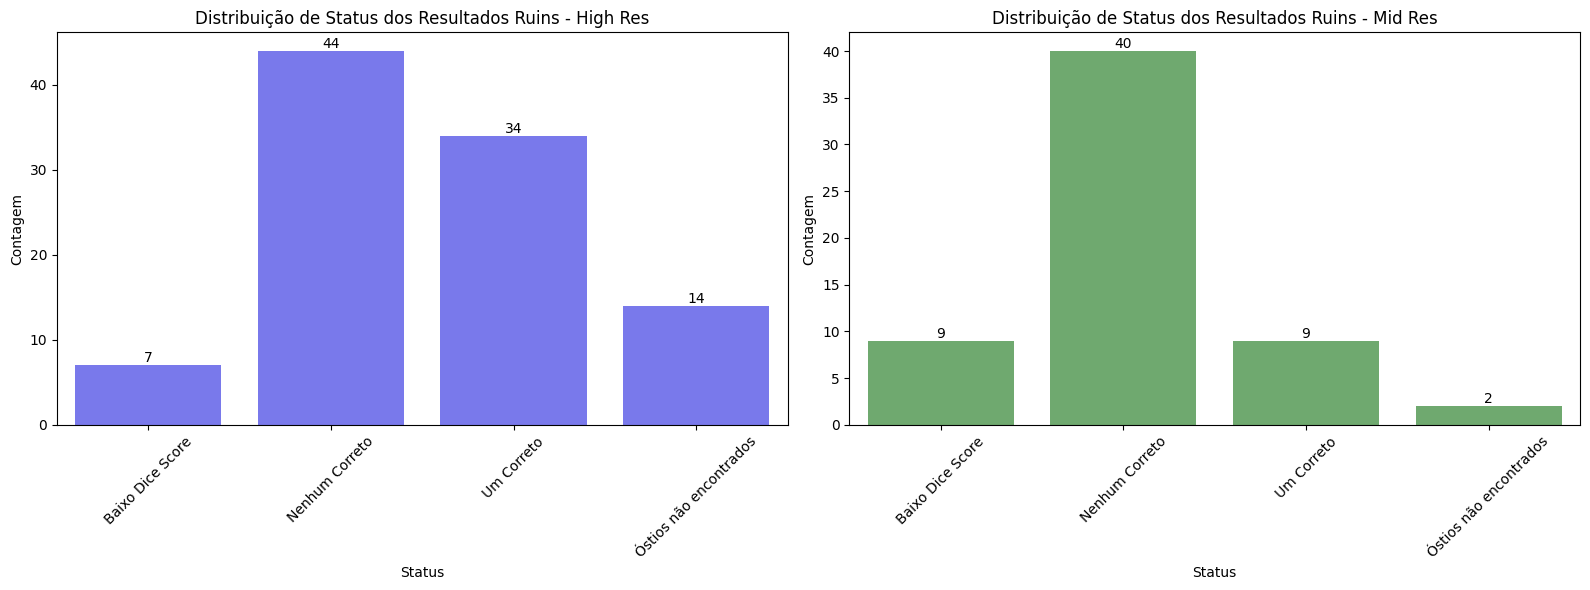

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

def change_status_label(status):
    if 'erro' in status:
        return 'Óstios não encontrados'
    elif 'ambos toleráveis' in status or 'ambos corretos' in status:
        return 'Baixo Dice Score'
    else:
        return status.title()

# High Res
high_res_status = df_high_bad_res['status'].value_counts()
high_res_status.index = high_res_status.index.map(change_status_label)
high_res_status = high_res_status.groupby(level=0).sum()
sns.barplot(x=high_res_status.index, y=high_res_status.values, color='blue', alpha=0.6, ax=axes[0])
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Contagem')
axes[0].set_title('Distribuição de Status dos Resultados Ruins - High Res')
axes[0].tick_params(axis='x', rotation=45)

# Adicionar valores nas barras - High Res
for p in axes[0].patches:
    height = p.get_height()
    axes[0].text(p.get_x() + p.get_width()/2., height,
                f'{int(height)}',
                ha="center", va="bottom")

# Mid Res
mid_res_status = df_mid_bad_res['status'].value_counts()
mid_res_status.index = mid_res_status.index.map(change_status_label)
mid_res_status = mid_res_status.groupby(level=0).sum()
sns.barplot(x=mid_res_status.index, y=mid_res_status.values, color='green', alpha=0.6, ax=axes[1])
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Contagem')
axes[1].set_title('Distribuição de Status dos Resultados Ruins - Mid Res')
axes[1].tick_params(axis='x', rotation=45)

# Adicionar valores nas barras - Mid Res
for p in axes[1].patches:
    height = p.get_height()
    axes[1].text(p.get_x() + p.get_width()/2., height,
                f'{int(height)}',
                ha="center", va="bottom")

plt.tight_layout()
plt.show()

Total de IMG_ID ruins em comum: 37
Mesmo status nos dois bancos: 16
Status diferente: 21


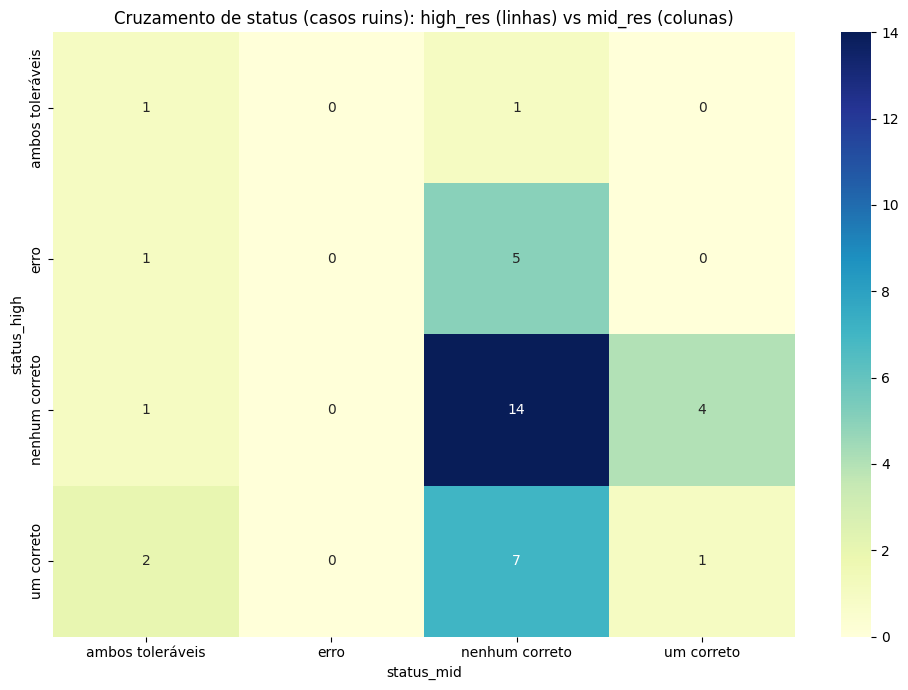


Amostra de IMG_ID com status diferente:


,IMG_ID,status_high,status_mid
0,867,erro,nenhum correto
2,553,um correto,nenhum correto
3,134,erro,nenhum correto
4,988,um correto,nenhum correto
5,459,um correto,nenhum correto
6,32,nenhum correto,um correto
7,606,erro,nenhum correto
9,960,um correto,nenhum correto
10,470,erro,ambos toleráveis
11,982,nenhum correto,um correto


In [55]:
# Comparacao por IMG_ID entre high_res e mid_res (apenas casos ruins)
status_compare = (
    df_high_bad_res[['IMG_ID', 'status']]
    .rename(columns={'status': 'status_high'})
    .merge(
        df_mid_bad_res[['IMG_ID', 'status']].rename(columns={'status': 'status_mid'}),
        on='IMG_ID',
        how='inner'
    )
)

if status_compare.empty:
    print('Nenhum IMG_ID em comum entre high_res e mid_res (casos ruins).')
else:
    # Normaliza para evitar diferencas de caixa/acento de digitacao
    status_compare['status_high_norm'] = status_compare['status_high'].str.strip().str.lower()
    status_compare['status_mid_norm'] = status_compare['status_mid'].str.strip().str.lower()
    status_compare['mesmo_status'] = status_compare['status_high_norm'] == status_compare['status_mid_norm']

    print('Total de IMG_ID ruins em comum:', len(status_compare))
    print('Mesmo status nos dois bancos:', int(status_compare['mesmo_status'].sum()))
    print('Status diferente:', int((~status_compare['mesmo_status']).sum()))

    # Lista completa de status (uniao) para garantir linhas/colunas simetricas
    status_levels = sorted(set(status_compare['status_high_norm']).union(status_compare['status_mid_norm']))

    # Matriz de cruzamento: mostra quais status de high viram quais em mid
    cross = pd.crosstab(status_compare['status_high_norm'], status_compare['status_mid_norm'])
    cross = cross.reindex(index=status_levels, columns=status_levels, fill_value=0)

    if cross.empty:
        print('Nao ha combinacoes de status para cruzamento.')
    else:
        plt.figure(figsize=(10, 7))
        sns.heatmap(cross, annot=True, fmt='d', cmap='YlGnBu')
        plt.title('Cruzamento de status (casos ruins): high_res (linhas) vs mid_res (colunas)')
        plt.xlabel('status_mid')
        plt.ylabel('status_high')
        plt.tight_layout()
        plt.show()

    # IDs onde houve divergencia de status (amostra)
    diff_ids = status_compare.loc[~status_compare['mesmo_status'], ['IMG_ID', 'status_high', 'status_mid']]
    print('\nAmostra de IMG_ID com status diferente:')
    display(diff_ids.head(20))